In [2]:
import kagglehub
import os
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import random
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer
from collections import defaultdict, Counter
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

c:\Users\Liam\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
path = kagglehub.dataset_download("rafsunahmad/popular-quotes-author-classifier")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\Liam\.cache\kagglehub\datasets\rafsunahmad\popular-quotes-author-classifier\versions\4


In [4]:
df = pd.read_csv(f"{path}/Autor_detection.csv")
df.head()

,Quotes,Writter name
0,Reading Kafka I sense that the elicited questi...,"Alberto Manguel,"
1,All animals are equal but some animals are mor...,George Orwell
2,I am old Gandalf I dont look it but I am begin...,J.R.R. Tolkien
3,How can we live without our lives How will we ...,John Steinbeck
4,I was only foolin George I dont want no ketchu...,John Steinbeck


In [5]:
# Remove rows with missing quotes or author names
df_clean = df.dropna(subset=['Quotes', 'Writter name'])
# Clean author names (remove trailing commas and extra spaces)
df_clean['Writter name'] = df_clean['Writter name'].str.strip().str.rstrip(',')

num_authors = df_clean['Writter name'].nunique()
print(f"Number of unique authors: {num_authors}")

# See the distribution of quotes per author
author_counts = df_clean['Writter name'].value_counts()
print("\nQuotes per author:")
print(author_counts)

num_quotes = len(df_clean)
print(f"\nTotal number of quotes: {num_quotes}")

X = df_clean['Quotes']
y = df_clean['Writter name']

Number of unique authors: 77

Quotes per author:
Writter name
Jane Austen            191
J.R.R. Tolkien         158
John Steinbeck         147
Charles Dickens        147
William Shakespeare    132
                      ... 
Thabo Jijana             1
Mark Fisher              1
Howard Eiland            1
Faruk Myrtaj             1
Kurt Vonnegut Jr.        1
Name: count, Length: 77, dtype: int64

Total number of quotes: 1571


C:\Users\Liam\AppData\Local\Temp\ipykernel_29644\1892367908.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['Writter name'] = df_clean['Writter name'].str.strip().str.rstrip(',')


In [6]:
class AuthorQuoteClassifier:
    def __init__(self, prior_type='uniform'):
        """
        prior_type: 'uniform', 'frequency', 'sqrt_frequency', 'log_frequency'
        """
        self.prior_type = prior_type
        self.authors_priors = {}
        self.word_probs = defaultdict(dict)
        self.vocabulary = set()
        self.authors = []
        
    def _calculate_priors(self, author_counts, n_docs):
        """
        Calculate prior probabilities based on prior_type
        """
        if self.prior_type == 'uniform':
            # All authors equally likely
            n_authors = len(author_counts)
            for author in author_counts.keys():
                self.authors_priors[author] = 1.0 / n_authors
                
        elif self.prior_type == 'frequency':
            # Prior based on training data frequency
            for author, count in author_counts.items():
                self.authors_priors[author] = count / n_docs
                
        elif self.prior_type == 'sqrt_frequency':
            # Dampened frequency prior
            sqrt_counts = {author: np.sqrt(count) 
                          for author, count in author_counts.items()}
            total = sum(sqrt_counts.values())
            for author, sqrt_count in sqrt_counts.items():
                self.authors_priors[author] = sqrt_count / total
                
        elif self.prior_type == 'log_frequency':
            # Logarithmic prior
            log_counts = {author: np.log(count + 1) 
                         for author, count in author_counts.items()}
            total = sum(log_counts.values())
            for author, log_count in log_counts.items():
                self.authors_priors[author] = log_count / total

        # If we find more we can add them
    
    def fit(self, X_train, y_train):
        """
        X_train: list of quotes
        y_train: list of authors
        """
        author_counts = defaultdict(int)
        word_counts = defaultdict(lambda: defaultdict(int))
        total_words_per_class = defaultdict(int)
        
        # Build vocabulary and count words
        for quote, author in zip(X_train, y_train):
            author_counts[author] += 1
            words = quote.lower().split()
            
            for word in words:
                self.vocabulary.add(word)
                word_counts[author][word] += 1
                total_words_per_class[author] += 1
        
        self.classes = list(author_counts.keys())
        n_docs = len(X_train)
        vocab_size = len(self.vocabulary)
        avg_quotes = n_docs / len(self.classes)
        
        # Calculate priors (P(author)) based on prior_type
        self._calculate_priors(author_counts, n_docs)
        
        # Calculate likelihoods (P(word|author)) with Laplace smoothing 
        # (Word_count + alpha) / (Total_words + Vocab_size * alpha)
        # We can play around with alpha more cause its not the greatest accuracy right now
        for author in self.classes:
            for word in self.vocabulary:
                word_count = word_counts[author][word]
                self.word_probs[author][word] = (
                    (word_count + 1) / 
                    (total_words_per_class[author] + vocab_size)
                )
    
    def predict_proba(self, quote):
        """
        Returns probability for each author
        P(author|words) proportional to P(author) * Π P(word|author)
        """
        words = quote.lower().split()
        posteriors = {}
        
        for author in self.classes:
            # Avoids underflow 
            log_posterior = np.log(self.authors_priors[author])
            
            for word in words:
                if word in self.vocabulary:
                    log_posterior += np.log(self.word_probs[author][word])
            
            posteriors[author] = log_posterior
        
        # Convert from log space and normalize
        max_log = max(posteriors.values())
        posteriors = {k: np.exp(v - max_log) for k, v in posteriors.items()}
        total = sum(posteriors.values())
        posteriors = {k: v/total for k, v in posteriors.items()}
        
        return posteriors
    
    def predict(self, quote):
        """Returns the most likely author"""
        probs = self.predict_proba(quote)
        return max(probs, key=probs.get)
    
    def get_prior_info(self):
        """Display prior information"""
        print(f"Prior type: {self.prior_type}")
        print(f"\nPrior probabilities (top 10):")
        sorted_priors = sorted(self.authors_priors.items(), 
                              key=lambda x: x[1], reverse=True)
        for author, prob in sorted_priors[:10]:
            print(f"  {author}: {prob:.4f}")

Original: 1571 quotes from 77 authors
Filtered: 1500 quotes from 19 authors
Training set: 1200 quotes
Test set: 300 quotes

Prior: uniform
Accuracy: 29.33%
Prior type: uniform

Prior probabilities (top 10):
  James Joyce: 0.0526
  Elias Canetti: 0.0526
  John Steinbeck: 0.0526
  Dante Alighieri: 0.0526
  Charles Dickens: 0.0526
  Jane Austen: 0.0526
  J.R.R. Tolkien: 0.0526
  William Faulkner: 0.0526
  William Shakespeare: 0.0526
  Ernest Hemingway: 0.0526
------------------------------------------------------------


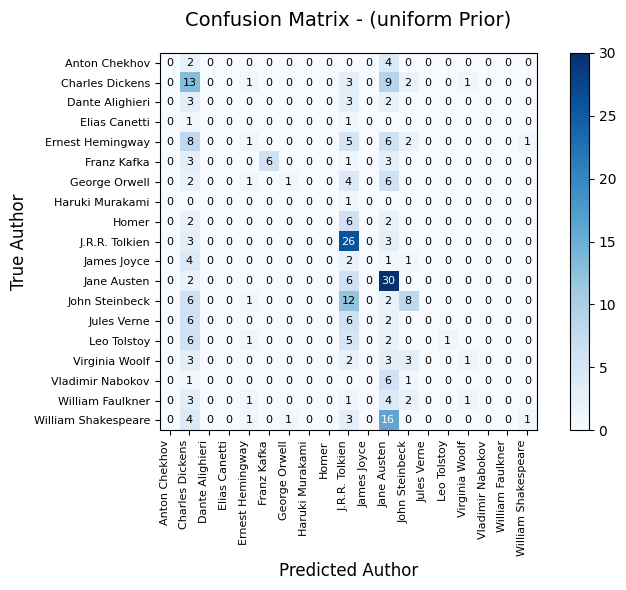


Prior: frequency
Accuracy: 28.67%
Prior type: frequency

Prior probabilities (top 10):
  Jane Austen: 0.1275
  J.R.R. Tolkien: 0.1050
  John Steinbeck: 0.0983
  Charles Dickens: 0.0983
  William Shakespeare: 0.0883
  Ernest Hemingway: 0.0758
  Leo Tolstoy: 0.0492
  Jules Verne: 0.0467
  George Orwell: 0.0458
  Franz Kafka: 0.0450
------------------------------------------------------------


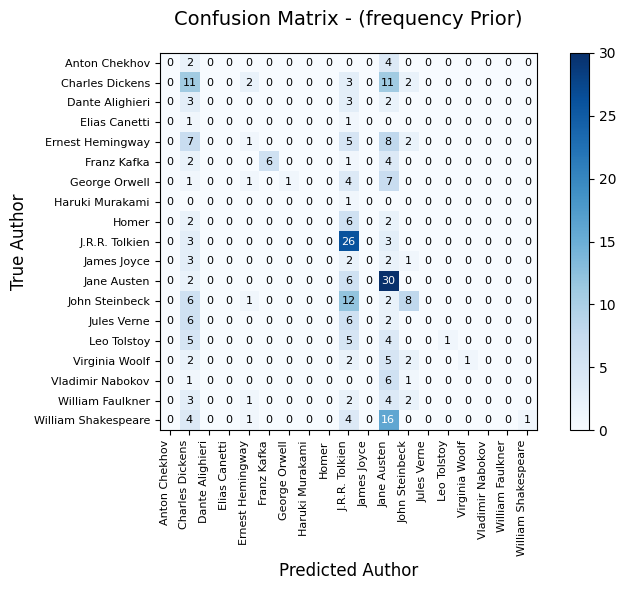


Prior: sqrt_frequency
Accuracy: 29.00%
Prior type: sqrt_frequency

Prior probabilities (top 10):
  Jane Austen: 0.0875
  J.R.R. Tolkien: 0.0794
  John Steinbeck: 0.0768
  Charles Dickens: 0.0768
  William Shakespeare: 0.0728
  Ernest Hemingway: 0.0675
  Leo Tolstoy: 0.0543
  Jules Verne: 0.0529
  George Orwell: 0.0524
  Franz Kafka: 0.0520
------------------------------------------------------------


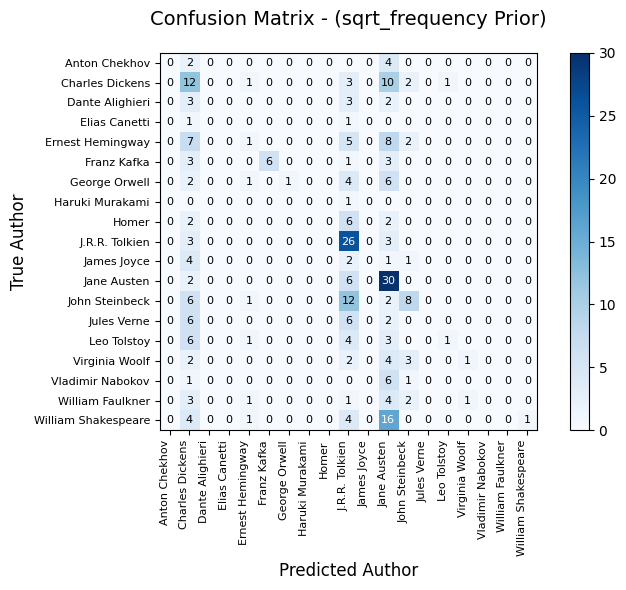


Prior: log_frequency
Accuracy: 29.33%
Prior type: log_frequency

Prior probabilities (top 10):
  Jane Austen: 0.0685
  J.R.R. Tolkien: 0.0659
  John Steinbeck: 0.0650
  Charles Dickens: 0.0650
  William Shakespeare: 0.0636
  Ernest Hemingway: 0.0615
  Leo Tolstoy: 0.0557
  Jules Verne: 0.0550
  George Orwell: 0.0548
  Franz Kafka: 0.0545
------------------------------------------------------------


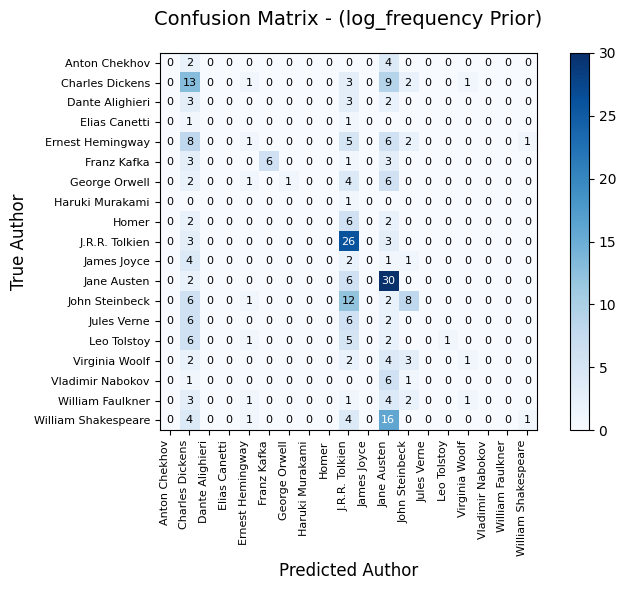


ACCURACY, PRECISION, RECALL, AND F1 SCORE SUMMARY
uniform: 29.33%, 31.19%, 29.33%, 21.45%
frequency: 28.67%, 40.23%, 28.67%, 20.98%
sqrt_frequency: 29.00%, 35.79%, 29.00%, 21.20%
log_frequency: 29.33%, 33.48%, 29.33%, 21.43%


In [15]:
min_quotes = 5 
filtered_data = [(quote, author) for quote, author in zip(X, y) 
                 if author_counts[author] >= min_quotes]

X_filtered = [item[0] for item in filtered_data]
y_filtered = [item[1] for item in filtered_data]

print(f"Original: {len(X)} quotes from {len(set(y))} authors")
print(f"Filtered: {len(X_filtered)} quotes from {len(set(y_filtered))} authors")

X_train, X_test, y_train, y_test = train_test_split(
    X_filtered, y_filtered, test_size=0.2, random_state=42, stratify=y_filtered
)

print(f"Training set: {len(X_train)} quotes")
print(f"Test set: {len(X_test)} quotes")

results = {}

prior_types = [
    'uniform',           
    'frequency',         
    'sqrt_frequency',    
    'log_frequency',     
]

print("="*60)

for prior in prior_types:
    model = AuthorQuoteClassifier(prior_type=prior)
    model.fit(X_train, y_train)
    
    predictions = [model.predict(quote) for quote in X_test]
    
    accuracy = sum(pred == true for pred, true in zip(predictions, y_test)) / len(y_test)
    precision, recall, f1, _ = classification_report(y_test, predictions, output_dict=True, zero_division=0)['weighted avg'].values()
    results[prior] = accuracy, precision, recall, f1
    
    print(f"\nPrior: {prior}")
    print(f"Accuracy: {accuracy:.2%}")
    model.get_prior_info()
    print("-"*60)

    # Only show the top 5 authors
    #top_authors = author_counts.head(5)
    #top_author_names = top_authors.index.tolist()
    #cm = confusion_matrix(y_test, predictions, labels=top_author_names)

    # show all authors
    all_authors = sorted(set(y_test))
    cm = confusion_matrix(y_test, predictions, labels=all_authors)

    # Plot confusion matrix
    plt.figure(figsize=(8, 6))
    plt.imshow(cm, interpolation='nearest', cmap='Blues')
    plt.title(f'Confusion Matrix - ({prior} Prior)', fontsize=14, pad=20)
    plt.colorbar()

    # Add author names
    tick_marks = np.arange(len(all_authors))
    #plt.xticks(tick_marks, top_author_names, rotation=90, ha='right')
    #plt.yticks(tick_marks, top_author_names)
    plt.xticks(tick_marks, all_authors, rotation=90, ha='right', fontsize=8)
    plt.yticks(tick_marks, all_authors, fontsize=8)

    # Add text annotations
    thresh = cm.max() / 2
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, format(cm[i, j], 'd'),
                    ha="center", va="center",
                    color="white" if cm[i, j] > thresh else "black",
                    fontsize=8)

    plt.ylabel('True Author', fontsize=12)
    plt.xlabel('Predicted Author', fontsize=12)
    plt.tight_layout()
    plt.show()

print("\n" + "="*60)
print("ACCURACY, PRECISION, RECALL, AND F1 SCORE SUMMARY")
print("="*60)
for prior, (acc, precision, recall, f1) in results.items():
    print(f"{prior}: {acc:.2%}, {precision:.2%}, {recall:.2%}, {f1:.2%}")

In [19]:
author_word_counts = {}
for author in df_clean['Writter name'].unique():
    # Get all quotes by this author
    author_quotes = df_clean[df_clean['Writter name'] == author]['Quotes']
    
    # Count total words across all their quotes
    total_words = 0
    for quote in author_quotes:
        words = str(quote).lower().split()
        total_words += len(words)
    
    author_word_counts[author] = total_words

# Sort by total word count
sorted_by_words = sorted(author_word_counts.items(), key=lambda x: x[1], reverse=True)

print("\nTop 10 authors by total word count in their quotes:")
for author, word_count in sorted_by_words[:10]:
    print(f"  {author}: {word_count} words")
    print(f"  Percentage of total words: {word_count / sum(author_word_counts.values()):.2%}\n")


Top 10 authors by total word count in their quotes:
  J.R.R. Tolkien: 5014 words
  Percentage of total words: 10.67%

  Jane Austen: 4915 words
  Percentage of total words: 10.46%

  Charles Dickens: 4774 words
  Percentage of total words: 10.16%

  John Steinbeck: 3991 words
  Percentage of total words: 8.49%

  Ernest Hemingway: 3315 words
  Percentage of total words: 7.06%

  Franz Kafka: 2832 words
  Percentage of total words: 6.03%

  Virginia Woolf: 2281 words
  Percentage of total words: 4.85%

  Leo Tolstoy: 2223 words
  Percentage of total words: 4.73%

  James Joyce: 1684 words
  Percentage of total words: 3.58%

  William Shakespeare: 1679 words
  Percentage of total words: 3.57%

